## EDA 3. Price Increase Threshold Modeling

#### 1. Overview
- There exists a price threshold beyond which churn risk accelerates non-linearly and substitution threat amplifies that tipping point 
- Price sensitivity differs structurally bt segment (Family vs Individual) and tenure cohort
- External substitution threat (Netflix alternative search intensity) acts as an amplifier that lowers the effective price threshold

#### 2. Research Hypothesis
- **Core Hypothesis**: Churn risk accelerates non-linearly beyond a price threshold, and this threshold is lowered when substitution threat is high
-**Sub Hypothesis**: Individual users reach their price threshold earlier than Family users use to higher per-capita cost burden 

#### 3. Key Inputs from H1 & H2
- H1: Segment X Price tier interaction confirms multiplicative churn risk (Fresh + High = 86.7%)
- H2: Family survivors show structurally lower churn sensitivity across all price tiers
- H3: Post-policy substitution search intensity increased +197% vs 76% for ad-free search --> substitution threat dominates



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

In [2]:
# Load data
df = pd.read_csv('../data/processed/cleaned_data.csv')
alt = pd.read_csv('../data/references/alternative_service_free_youtube.csv')

In [3]:
df.shape

(5534, 21)

In [4]:
print(df['Churn'].value_counts())

Churn
No     4063
Yes    1471
Name: count, dtype: int64


### 3.1. Data Preparation
Apply consistent filtering conditions from EDA 01 & 02
- calculated_tenure: reverse-engined from TotalCharges / MonthlyCharges
- Exclude July 2025 outlier (calculated_tenure == 7): confirmed as statistical noise in EDA 01
- Segment definition consistent with EDA 01 tenure cohorts

In [5]:

# Consistenct processing from EDA 01 and EDA 02
df['calculated_tenure'] = (df['TotalCharges'] / df['MonthlyCharges']).round().fillna(0).astype(int)

# Exclude July 2025 outlier (Validated EDA 01)
baseline = df[df['calculated_tenure'] !=7]

# Tenure segments (consistent with EDA 01)
def categorize_tenure(t):
    if t >= 5: return 'Pre-Inflection (5mo+)'   # Before Sep 2025
    elif t >= 3: return 'Inflection (3-5mo)'    # Sep-Oct 2025 - Policy shock period
    else: return 'Fresh (<3mo)'                 # After Nov 2025

df['Segment'] = df['calculated_tenure'].apply(categorize_tenure)

# Price tier: qcut (equal size, consistent with EDA 01)
# Low: $18~$50 / Medium: $50~$84 / High: $84~$118
df['PriceTier'] = pd.qcut(df['MonthlyCharges'], q=3, labels=['Low', 'Medium', 'High'])

# Family vs Individual (consistent with EDA 02)
df['is_family'] = (df['Partner'] == 'Yes' )| (df['Dependents'] == 'Yes')
df['segment_type'] = df['is_family'].map({True: 'Family', False: 'Individual'})

print(f"Segment distribution:\n{df['Segment'].value_counts()}")
print(f"\nFamily vs Individual:\n{df['segment_type'].value_counts()}")

Segment distribution:
Segment
Pre-Inflection (5mo+)    4598
Fresh (<3mo)              639
Inflection (3-5mo)        297
Name: count, dtype: int64

Family vs Individual:
segment_type
Family        2964
Individual    2570
Name: count, dtype: int64


### 3.2. Price threshold Analyst

#### 3.2.1. Baseline: Natural Churn Rate
- Overall churn rate without price increase context
- Family vs Individual natural churn baseline

In [6]:
# Natural Churn Rate baseline (Full dataset, July excluded)
total = len(df)
churned = (df['Churn'] == 'Yes').sum()
natural_churn = churned / total * 100
print(f"Total Customers: {total}")
print(f"Churned Customers: {churned}")
print(f"Overall Churn Rate: {natural_churn:.2f}%")

# family_natural = df[df['is_family']]['Churn'].value_counts(normalize=True)['Yes'] * 100 --> if no Yes, this will error out
family_churn = df[df['is_family']]['Churn'].value_counts(normalize=True).get('Yes', 0) * 100    # if no Yes, default to 0%
individual_churn = df[~df['is_family']]['Churn'].value_counts(normalize=True).get('Yes', 0) * 100

print(f"Family Churn Rate: {family_churn:.2f}%")
print(f"Individual Churn Rate: {individual_churn:.2f}%")

Total Customers: 5534
Churned Customers: 1471
Overall Churn Rate: 26.58%
Family Churn Rate: 20.14%
Individual Churn Rate: 34.01%


#### 3.2.2. Churn Rate by Segment X Proce Tier X Family/Individual
- Extends EDA 01 analysis by adding Family/Individual dimension
- **NOTE**: Inflection(3-5 mo) segment represents policy shock response, not pure price sensitivity
  - These customers joined Sep - Oct 2025, experienced policy change immediately
  - Their churn reflects policy betrayal effect, not price threshold behavior

In [7]:
# Churn Rate by Segment X Price Tier X Family/Individual
churn_rates = df.groupby(['Segment', 'PriceTier', 'segment_type'])['Churn'].value_counts(normalize=True).unstack(fill_value=0)['Yes'] * 100
print("\nChurn Rates by Segment, Price Tier, and Family/Individual:")
print(churn_rates)



Churn Rates by Segment, Price Tier, and Family/Individual:
Segment                PriceTier  segment_type
Fresh (<3mo)           Low        Family          46.052632
                                  Individual      43.265306
                       Medium     Family          63.157895
                                  Individual      75.124378
                       High       Family          83.333333
                                  Individual      88.095238
Inflection (3-5mo)     Low        Family          25.531915
                                  Individual      37.179487
                       Medium     Family          62.857143
                                  Individual      50.588235
                       High       Family          87.500000
                                  Individual      61.111111
Pre-Inflection (5mo+)  Low        Family           6.781751
                                  Individual      11.375212
                       Medium     Family          17.

C:\Users\irene\AppData\Local\Temp\ipykernel_17196\1842204754.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rates = df.groupby(['Segment', 'PriceTier', 'segment_type'])['Churn'].value_counts(normalize=True).unstack(fill_value=0)['Yes'] * 100


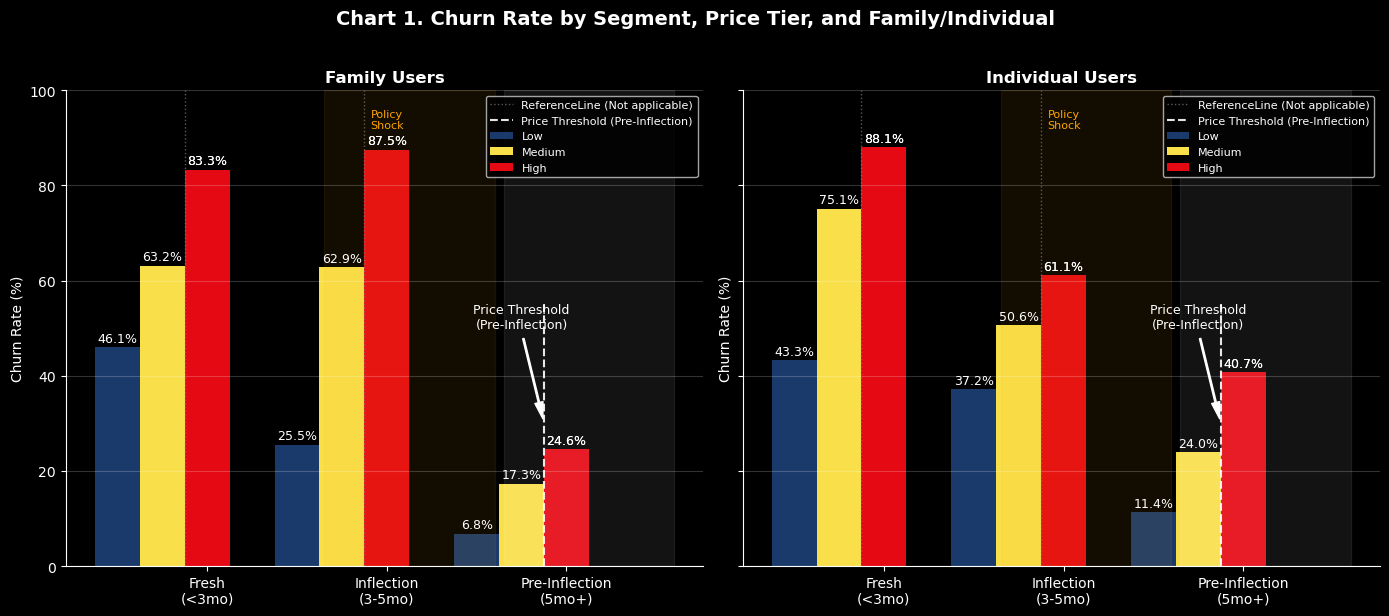

In [12]:
# Visualization - Grouped Bar Chart
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle('Chart 1. Churn Rate by Segment, Price Tier, and Family/Individual', fontsize=14, fontweight='bold', y=1.02)
segment_order = ['Fresh (<3mo)', 'Inflection (3-5mo)', 'Pre-Inflection (5mo+)']
price_tiers = ['Low', 'Medium', 'High']
colors = {'Low': '#1a3a6b', 'Medium': '#f9e04b', 'High': '#e50914'}

x = np.arange(len(segment_order))
width = 0.25

for idx, seg_type in enumerate(['Family', 'Individual']):
    for i, price in enumerate(price_tiers):
        vals = [churn_rates.get((seg, price, seg_type), 0) 
                for seg in segment_order]
        bars = axes[idx].bar(x + (i - 1) * width, vals, width, label=price, color=colors[price])
    
        # Value labels on bars
        for bar in bars:
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{height:.1f}%', 
                           ha='center', va='bottom', fontsize=9, color='white')

    # Value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{height:.1f}%', 
                       ha='center', va='bottom', fontsize=9, color='white')
        
    # Threshold and Reference Lines
    for seg_idx in range(3):
        threshold_x = x[seg_idx] + 0.5 * width   # Position threshold line between Medium and High

        if seg_idx ==2:  # Pre-Inflection segment
            axes[idx].plot([threshold_x, threshold_x], [0, 55], color='white', linestyle='--', linewidth=1.5, alpha=0.9,label='Price Threshold (Pre-Inflection)')

            # Annotation on Medium bar with arrow pointing --> to threshold line
            text_x = threshold_x - 0.5 * width
            axes[idx].annotate('Price Threshold\n(Pre-Inflection)', xy=(threshold_x, 30), xytext=(text_x, 50),
                        arrowprops=dict(facecolor='white', shrink=0.05, width=1, headwidth=6), fontsize=9, color='white', ha='center')
        
        else:   # For Fresh and Inflection segments: grey dotted (Reference Only)
            axes[idx].plot([threshold_x, threshold_x], [0, 100], color='grey', linestyle=':', linewidth=1, alpha=0.7, label='ReferenceLine (Not applicable)' if seg_idx==0 else '' )


    # Zone Highlighting
    # Pre-Inflection: Highlight High Price Tier zone (above threshold) with red shade
    axes[idx].axvspan(x[2] - 0.1, x[2] + 3*width + 0.1, alpha=0.08, color='white')

    # Infection zone:policy shock label
    axes[idx].axvspan(x[1] - 0.1, x[1] + 3*width + 0.1, alpha=0.08, color='orange')
    axes[idx].text(x[1] + width, 92, 'Policy\nShock',
            ha='center', color='orange', fontsize=8)
    
    # Axes formatting
    axes[idx].set_title(f"{seg_type} Users", fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x + width)
    axes[idx].set_xticklabels(['Fresh\n(<3mo)', 'Inflection\n(3-5mo)', 'Pre-Inflection\n(5mo+)'], fontsize=10)
    axes[idx].set_ylabel('Churn Rate (%)', fontsize=10)
    axes[idx].set_ylim(0, 100)
    axes[idx].legend(fontsize=8, title_fontsize=9, loc='upper right')
    axes[idx].grid(axis='y', alpha=0.2)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/eda_03/graph1_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()
